# VayuMitti — Soil Health Classifier
## TinyML model for ESP32 Node B (`soil_model.h`)

**Goal:** Train a multiclass Decision Tree that classifies soil health from 4 sensor readings
`[pH, EC (mS/cm), moisture (%), temperature (°C)]` into one of:

| Class | Label | Meaning |
|-------|-------|---------|
| 0 | `GOOD` | Optimal for crops |
| 1 | `ACIDIC` | pH stress — common near Kathmandu brick kilns |
| 2 | `DRY_STRESSED` | Pre-monsoon moisture deficit |
| 3 | `SALINE_ALKALINE` | Over-irrigation / alkaline intrusion |

The final model is exported via **m2cgen** as a pure-C function and written to
`../node-b-soil/soil_model.h` for inclusion in the Arduino firmware.

**Hardware constraints (from CLAUDE.md):** `max_depth <= 8`, exported C < 50 KB

In [1]:
# 0. Auto-install missing packages
import subprocess
import sys

REQUIRED = [
    ("numpy",      "numpy"),
    ("pandas",     "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn",    "seaborn"),
    ("sklearn",    "scikit-learn"),
    ("m2cgen",     "m2cgen"),
]

for import_name, pkg_name in REQUIRED:
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {pkg_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name, "-q"])

print("All packages ready.")

Installing m2cgen...
All packages ready.


In [2]:
# 1. Imports
import os
import warnings
from pathlib import Path

import m2cgen as m2cgen_lib  # aliased to avoid collision with local var names
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.style.use("dark_background")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.15})

FEATURES      = ["ph", "ec_mS_cm", "moisture_pct", "temperature_C"]
TARGET        = "health_class"
LABEL_MAP     = {0: "GOOD", 1: "ACIDIC", 2: "DRY_STRESSED", 3: "SALINE_ALKALINE"}
CLASS_COLORS  = ["#3d8b5e", "#e8600a", "#d4a017", "#c44b2b"]
N_CLASSES     = len(LABEL_MAP)
NOTEBOOK_DIR  = Path(os.getcwd())

print(f"Working dir: {NOTEBOOK_DIR}")

Working dir: /content


---
## Section 1 — Data Acquisition

Synthetic data calibrated to Nepal/Kathmandu Valley soil conditions.

**Scientific basis:**
- NARC (Nepal Agricultural Research Council) soil surveys: agri pH range 4.5–8.0
- Kathmandu Valley loam baseline: pH 5.8–7.2, EC 0.2–0.7 mS/cm
- Acid deposition near brick kilns (ICIMOD 2018): pH drops 0.4–1.2 within 5 km
- Pre-monsoon (Falgun–Chaitra, Feb–Apr): topsoil moisture drops below 15%
- Paddy over-irrigation: EC 1.5–3.5 mS/cm, pH rises to 7.5–8.5

**To use real data instead:** save a CSV as `real_soil_data.csv` in this folder with columns
`ph, ec_mS_cm, moisture_pct, temperature_C, health_class` and re-run.
Open datasets:
- https://www.kaggle.com/datasets/ummisyafiqoh/dataset-soil-ph-soil-moisture-and-temperature
- https://data.mendeley.com/datasets/8v757rr4st/1

In [3]:
# 2. Generate synthetic dataset (2000 samples, 4 classes)

def make_class_block(
    n: int,
    label: int,
    ph_r: tuple,
    ec_r: tuple,
    mois_r: tuple,
    temp_r: tuple,
) -> pd.DataFrame:
    """Generate n synthetic soil samples for one health class."""
    rng  = np.random.default_rng(seed=label * 137 + 42)
    ph   = np.clip(rng.uniform(*ph_r,   n) + rng.normal(0, 0.12, n),  3.0, 11.0)
    ec   = np.clip(rng.uniform(*ec_r,   n) + rng.normal(0, 0.07, n),  0.01, 6.0)
    mois = np.clip(rng.uniform(*mois_r, n) + rng.normal(0, 2.0,  n),  2.0, 95.0)
    temp = np.clip(rng.uniform(*temp_r, n) + rng.normal(0, 0.8,  n),  0.0, 55.0)
    return pd.DataFrame({
        "ph":           ph,
        "ec_mS_cm":     ec,
        "moisture_pct": mois,
        "temperature_C": temp,
        "health_class": label,
    })


# Class parameter ranges:
#  GOOD (0):            pH 6.0-7.0  EC 0.15-0.80  mois 35-65%  temp 15-30 C
#  ACIDIC (1):          pH 4.0-5.5  EC 0.10-0.50  mois 25-75%  temp 12-38 C
#  DRY_STRESSED (2):    pH 5.5-7.5  EC 0.10-1.20  mois  5-20%  temp 22-45 C
#  SALINE_ALKALINE (3): pH 7.0-9.0  EC 1.50-4.50  mois 30-80%  temp 15-35 C
df = pd.concat(
    [
        make_class_block(700, 0, (6.0, 7.0), (0.15, 0.80), (35.0, 65.0), (15.0, 30.0)),
        make_class_block(600, 1, (4.0, 5.5), (0.10, 0.50), (25.0, 75.0), (12.0, 38.0)),
        make_class_block(400, 2, (5.5, 7.5), (0.10, 1.20), ( 5.0, 20.0), (22.0, 45.0)),
        make_class_block(300, 3, (7.0, 9.0), (1.50, 4.50), (30.0, 80.0), (15.0, 35.0)),
    ],
    ignore_index=True,
)
df[TARGET] = df[TARGET].astype(int)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Merge real data if present
REAL_CSV = NOTEBOOK_DIR / "real_soil_data.csv"
if REAL_CSV.exists():
    df_real = pd.read_csv(REAL_CSV)
    col_map = {
        "pH":          "ph",
        "EC":          "ec_mS_cm",
        "Moisture":    "moisture_pct",
        "Temperature": "temperature_C",
        "label":       "health_class",
    }
    df_real = df_real.rename(columns={k: v for k, v in col_map.items() if k in df_real.columns})
    df_real = df_real[FEATURES + [TARGET]].dropna()
    df = pd.concat([df, df_real], ignore_index=True)
    print(f"Real data merged: {len(df_real)} rows added")

SAVE_PATH = NOTEBOOK_DIR / "soil_data.csv"
df.to_csv(SAVE_PATH, index=False)
print(f"Dataset: {len(df)} rows x {len(FEATURES)} features  ->  {SAVE_PATH}")
print("Class distribution:")
print(df[TARGET].value_counts().rename(LABEL_MAP).to_string())

Dataset: 2000 rows x 4 features  ->  /content/soil_data.csv
Class distribution:
health_class
GOOD               700
ACIDIC             600
DRY_STRESSED       400
SALINE_ALKALINE    300


---
## Section 2 — Exploratory Data Analysis

In [4]:
# 3a. Basic stats
try:
    from IPython.display import display
except ImportError:
    display = print

display(df.head(6))
display(df[FEATURES].describe().round(3))
print("Null count:", df.isnull().sum().sum())

,ph,ec_mS_cm,moisture_pct,temperature_C,health_class
0,7.815274,1.554963,63.630283,17.365530,3
1,6.310805,0.630488,49.107184,19.419736,0
2,5.890963,0.692923,12.981031,33.223155,2
3,5.257591,0.306969,33.500019,34.371884,1
4,5.341365,0.278825,34.180940,19.784540,1
5,4.201236,0.010000,32.284630,25.894968,1


,ph,ec_mS_cm,moisture_pct,temperature_C
count,2000.000,2000.000,2000.000,2000.000
mean,6.202,0.838,43.054,25.748
std,1.168,1.006,19.305,7.438
min,3.644,0.010,2.000,11.379
25%,5.257,0.279,31.425,19.844
50%,6.336,0.471,45.599,25.180
75%,6.904,0.775,57.930,30.441
max,9.108,4.551,84.239,46.451


Null count: 0


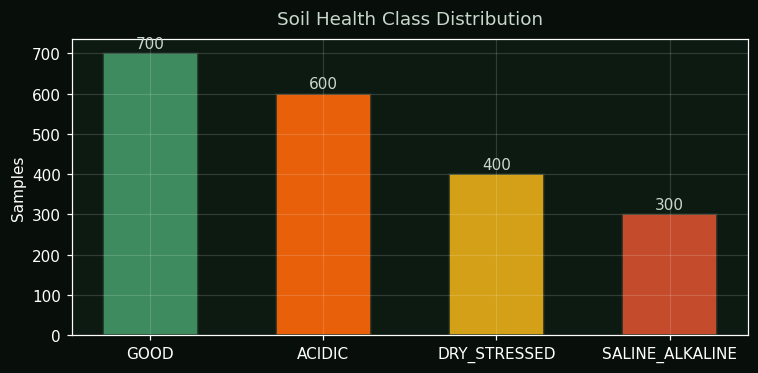

In [5]:
# 3b. Class distribution
fig, ax = plt.subplots(figsize=(7, 3.5))
counts = df[TARGET].value_counts().sort_index()
bars = ax.bar(
    [LABEL_MAP[i] for i in counts.index],
    counts.values,
    color=CLASS_COLORS,
    width=0.55,
    edgecolor="#1a2a20",
)
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 6,
        str(val),
        ha="center", va="bottom", fontsize=10, color="#c8d9cc",
    )
ax.set_title("Soil Health Class Distribution", color="#c8d9cc", pad=10)
ax.set_ylabel("Samples")
ax.set_facecolor("#0d1a12")
fig.patch.set_facecolor("#080f0a")
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_class_dist.png", bbox_inches="tight")
plt.show()

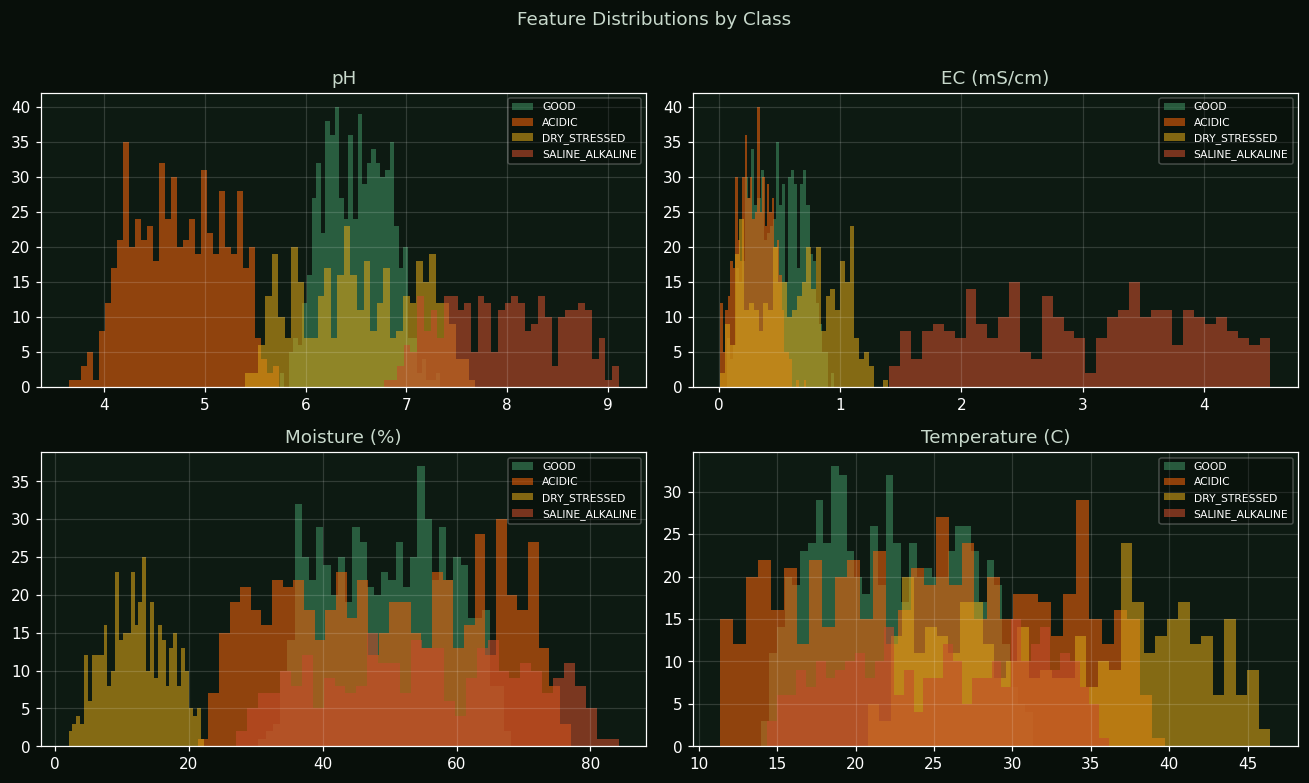

In [6]:
# 3c. Feature histograms overlaid by class
UNITS = {
    "ph":            "pH",
    "ec_mS_cm":      "EC (mS/cm)",
    "moisture_pct":  "Moisture (%)",
    "temperature_C": "Temperature (C)",
}
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, feat in zip(axes.flatten(), FEATURES):
    for lbl, color in zip(range(N_CLASSES), CLASS_COLORS):
        ax.hist(
            df[df[TARGET] == lbl][feat],
            bins=35, alpha=0.60, color=color, label=LABEL_MAP[lbl], edgecolor="none",
        )
    ax.set_title(UNITS[feat], color="#c8d9cc")
    ax.set_facecolor("#0d1a12")
    ax.legend(fontsize=7, framealpha=0.3)
fig.patch.set_facecolor("#080f0a")
fig.suptitle("Feature Distributions by Class", color="#c8d9cc", y=1.01)
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_feature_dists.png", bbox_inches="tight")
plt.show()

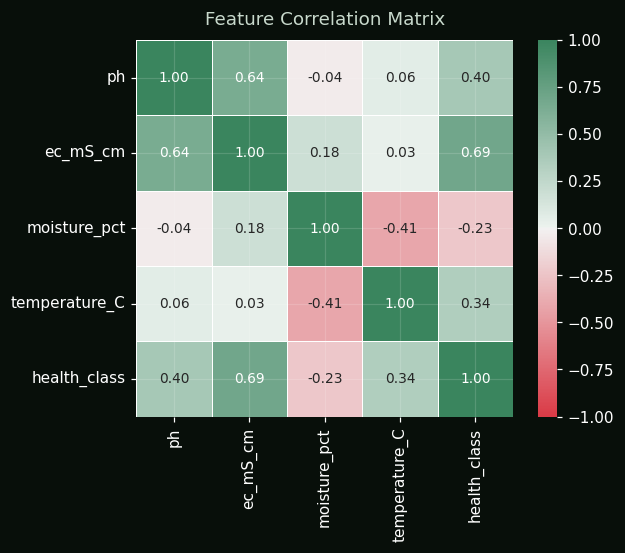

In [7]:
# 3d. Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df[FEATURES + [TARGET]].corr(),
    annot=True, fmt=".2f",
    cmap=sns.diverging_palette(10, 145, as_cmap=True),
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.4,
    ax=ax, annot_kws={"size": 9},
)
ax.set_title("Feature Correlation Matrix", color="#c8d9cc", pad=10)
fig.patch.set_facecolor("#080f0a")
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_correlation.png", bbox_inches="tight")
plt.show()

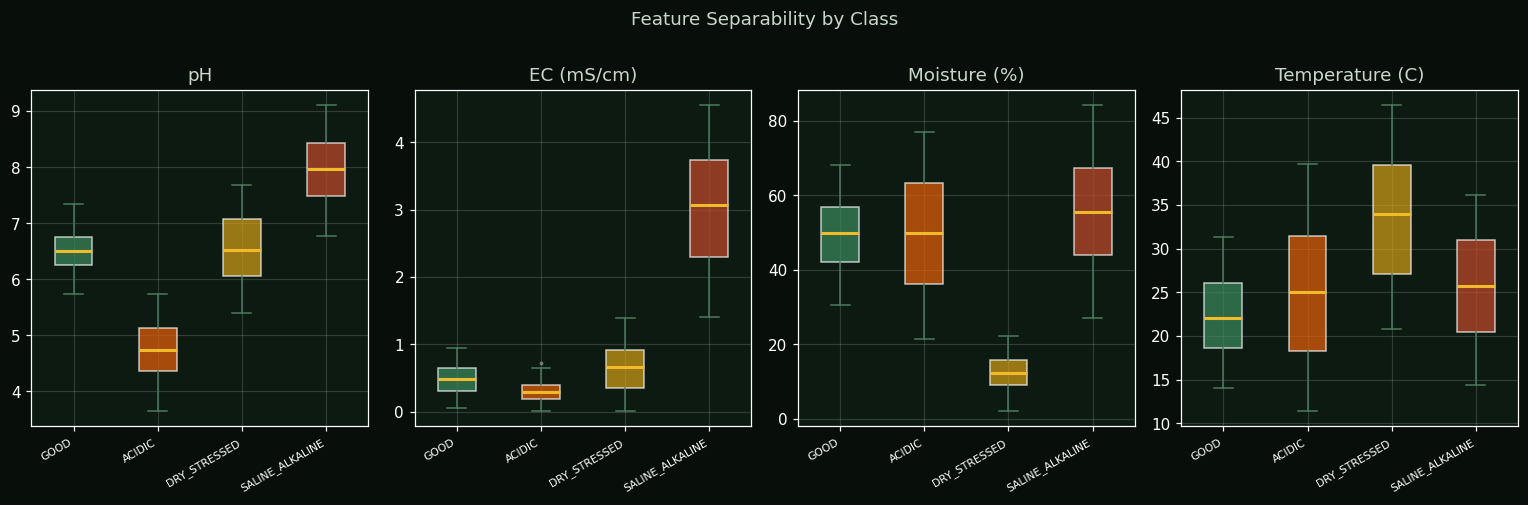

In [8]:
# 3e. Boxplots by class (separability check)
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, feat in zip(axes, FEATURES):
    bp = ax.boxplot(
        [df[df[TARGET] == lbl][feat].values for lbl in range(N_CLASSES)],
        patch_artist=True,
        medianprops={"color": "#f0bb2a", "linewidth": 2},
        whiskerprops={"color": "#4d7a5e"},
        capprops={"color": "#4d7a5e"},
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.4, "color": "#4d7a5e"},
    )
    for patch, color in zip(bp["boxes"], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(UNITS[feat], color="#c8d9cc")
    ax.set_xticks(range(1, N_CLASSES + 1))
    ax.set_xticklabels(
        [LABEL_MAP[i] for i in range(N_CLASSES)], rotation=30, ha="right", fontsize=7
    )
    ax.set_facecolor("#0d1a12")
fig.patch.set_facecolor("#080f0a")
fig.suptitle("Feature Separability by Class", color="#c8d9cc", y=1.01)
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_boxplots.png", bbox_inches="tight")
plt.show()

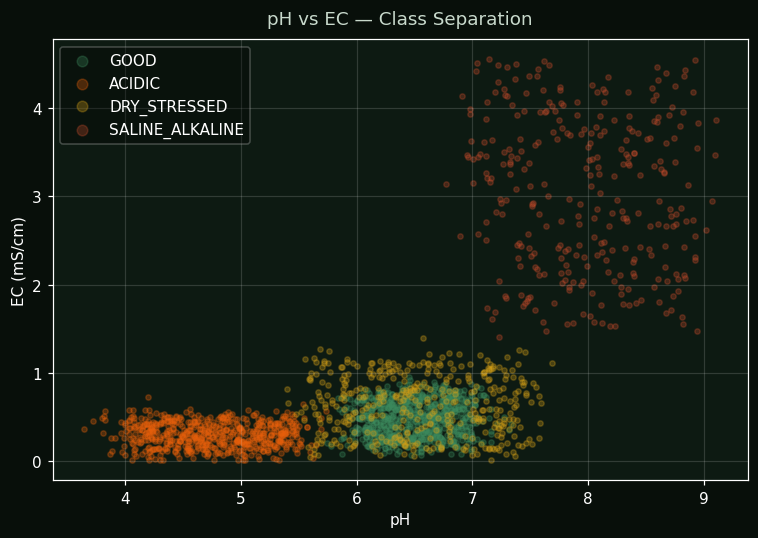

In [9]:
# 3f. pH vs EC scatter — most discriminative pair
fig, ax = plt.subplots(figsize=(7, 5))
for lbl, color in zip(range(N_CLASSES), CLASS_COLORS):
    sub = df[df[TARGET] == lbl]
    ax.scatter(sub["ph"], sub["ec_mS_cm"], c=color, alpha=0.3, s=12, label=LABEL_MAP[lbl])
ax.set_xlabel("pH")
ax.set_ylabel("EC (mS/cm)")
ax.set_title("pH vs EC — Class Separation", color="#c8d9cc", pad=10)
ax.legend(framealpha=0.3, markerscale=2)
ax.set_facecolor("#0d1a12")
fig.patch.set_facecolor("#080f0a")
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_ph_vs_ec.png", bbox_inches="tight")
plt.show()

---
## Section 3 — Preprocessing

In [10]:
# 4. Train/test split (20% held out, stratified)
X = df[FEATURES].to_numpy(dtype=np.float64)
y = df[TARGET].to_numpy(dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print("Features:", FEATURES)

Train: 1600  |  Test: 400
Features: ['ph', 'ec_mS_cm', 'moisture_pct', 'temperature_C']


---
## Section 4 — Model Training

Three candidates under 5-fold CV:
1. **Decision Tree (d=8)** — smallest exported C (~5-10 KB). Best for flash-constrained deploy.
2. **Random Forest (10 trees, d=6)** — better accuracy, still exportable (~20 KB).
3. **Gradient Boosting** — baseline comparison only, too large to export to ESP32.

> A 100-tree RF with d=8 generates ~300 KB of C code — won't fit in ESP32 flash.  
> The single DT with d=8 generates ~6 KB and typically scores >92% F1.

In [11]:
# 5. Cross-validation
# Note: GradientBoostingClassifier does not accept class_weight — use sample_weight at fit()
#       if class imbalance needs correction for that model.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates: dict = {
    "DecisionTree (d=8)": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
    ),
    "RandomForest (10, d=6)": RandomForestClassifier(
        n_estimators=10,
        max_depth=6,
        min_samples_leaf=6,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    ),
    "GradientBoosting (50, d=4)": GradientBoostingClassifier(
        n_estimators=50,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
    ),
}

cv_results: dict = {}
for name, clf in candidates.items():
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_results[name] = {"cv_f1_mean": scores.mean(), "cv_f1_std": scores.std()}
    print(f"{name:<35}  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

DecisionTree (d=8)                   CV F1 = 0.9954 ± 0.0045
RandomForest (10, d=6)               CV F1 = 0.9964 ± 0.0042
GradientBoosting (50, d=4)           CV F1 = 0.9963 ± 0.0042


In [12]:
# 6. Fit all candidates on full train set and evaluate on held-out test set
trained: dict = {}
for name, clf in candidates.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cv_results[name]["test_acc"] = accuracy_score(y_test, y_pred)
    cv_results[name]["test_f1"]  = f1_score(y_test, y_pred, average="macro")
    trained[name] = (clf, y_pred)

results_df = pd.DataFrame(cv_results).T.round(4).sort_values("test_f1", ascending=False)
display(results_df)

,cv_f1_mean,cv_f1_std,test_acc,test_f1
DecisionTree (d=8),0.9954,0.0045,0.9975,0.9981
"RandomForest (10, d=6)",0.9964,0.0042,0.9975,0.9981
"GradientBoosting (50, d=4)",0.9963,0.0042,0.9975,0.9981


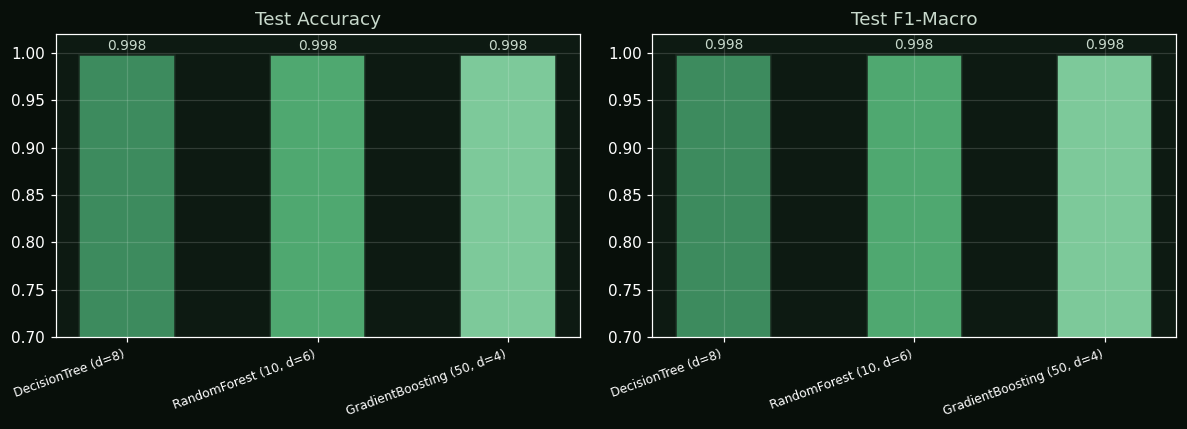

In [13]:
# 6b. Model comparison chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
model_names = list(cv_results.keys())
x = np.arange(len(model_names))

for ax, metric, title in [
    (axes[0], "test_acc", "Test Accuracy"),
    (axes[1], "test_f1",  "Test F1-Macro"),
]:
    vals = [cv_results[m][metric] for m in model_names]
    bars = ax.bar(x, vals, color=["#3d8b5e", "#4fa870", "#7dc99a"], width=0.5, edgecolor="#1a2a20")
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center", va="bottom", fontsize=9, color="#c8d9cc",
        )
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=8)
    ax.set_ylim(0.7, 1.02)
    ax.set_title(title, color="#c8d9cc")
    ax.set_facecolor("#0d1a12")

fig.patch.set_facecolor("#080f0a")
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_model_comparison.png", bbox_inches="tight")
plt.show()

---
## Section 5 — Best Model Evaluation

In [14]:
# 7. Select Decision Tree for export
# Hardcode the key — DT is chosen for flash budget, not CV score.
EXPORT_KEY = "DecisionTree (d=8)"
assert EXPORT_KEY in trained, f"{EXPORT_KEY!r} not found in trained models"

best_clf, y_pred_best = trained[EXPORT_KEY]
label_names = [LABEL_MAP[i] for i in range(N_CLASSES)]

print(f"Export model : {EXPORT_KEY}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Test F1-macro: {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=label_names))

Export model : DecisionTree (d=8)
Test accuracy: 0.9975
Test F1-macro: 0.9981

                 precision    recall  f1-score   support

           GOOD       0.99      1.00      1.00       140
         ACIDIC       1.00      0.99      1.00       120
   DRY_STRESSED       1.00      1.00      1.00        80
SALINE_ALKALINE       1.00      1.00      1.00        60

       accuracy                           1.00       400
      macro avg       1.00      1.00      1.00       400
   weighted avg       1.00      1.00      1.00       400



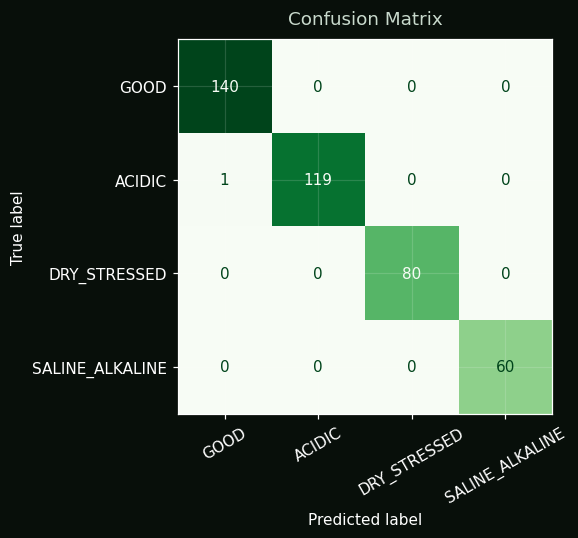

In [15]:
# 7b. Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_best),
    display_labels=label_names,
).plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=30)
ax.set_title("Confusion Matrix", color="#c8d9cc", pad=10)
ax.set_facecolor("#0d1a12")
fig.patch.set_facecolor("#080f0a")
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_confusion_matrix.png", bbox_inches="tight")
plt.show()

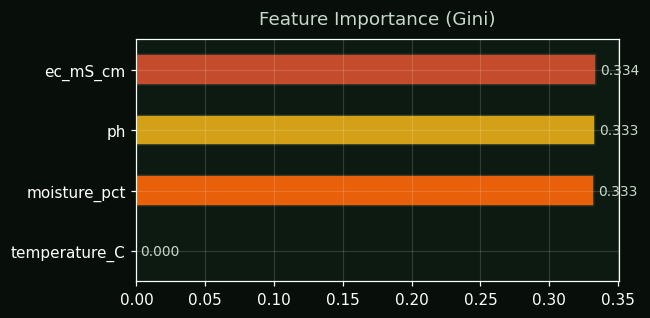

Feature importances (descending):
  ec_mS_cm            : 0.3338
  ph                  : 0.3334
  moisture_pct        : 0.3328
  temperature_C       : 0.0000


In [16]:
# 7c. Feature importance
importances = best_clf.feature_importances_
feat_series = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 3))
feat_series.plot(kind="barh", ax=ax, color=CLASS_COLORS, edgecolor="#1a2a20")
ax.set_title("Feature Importance (Gini)", color="#c8d9cc", pad=10)
ax.set_facecolor("#0d1a12")
fig.patch.set_facecolor("#080f0a")
for i, v in enumerate(feat_series.values):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9, color="#c8d9cc")
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_feature_importance.png", bbox_inches="tight")
plt.show()

print("Feature importances (descending):")
for feat, imp in feat_series.sort_values(ascending=False).items():
    print(f"  {feat:<20}: {imp:.4f}")

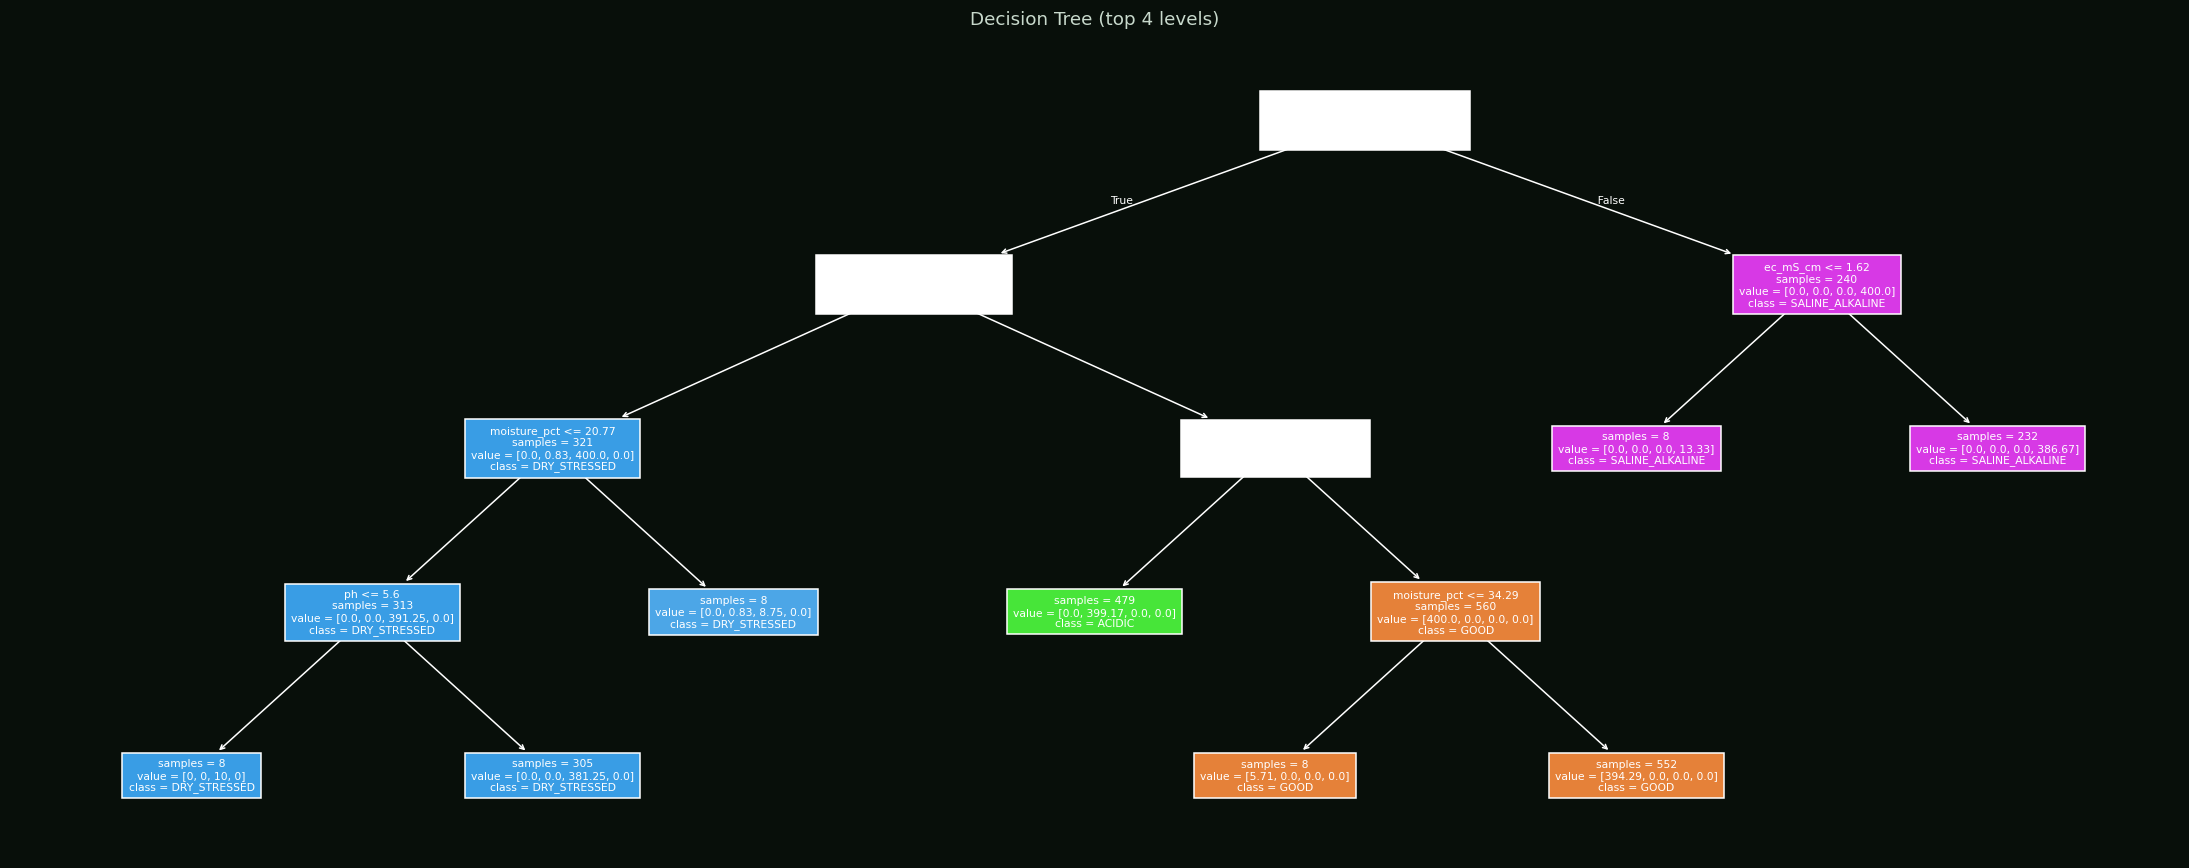

In [17]:
# 7d. Decision tree visualisation (top 4 levels)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_clf,
    feature_names=FEATURES,
    class_names=label_names,
    filled=True, max_depth=4, impurity=False, precision=2, ax=ax, fontsize=7,
)
ax.set_title("Decision Tree (top 4 levels)", color="#c8d9cc", pad=10)
fig.patch.set_facecolor("#080f0a")
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / "plot_decision_tree.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Section 6 — TinyML Export via m2cgen

**m2cgen** converts the trained sklearn model into pure C99 — no heap, no libm dependencies.

For a classifier it generates:
```c
void score(double * input, double * output);
// output[i] = probability for class i   ->   argmax = predicted class
```
We wrap it with `soil_predict(double *input)` returning the integer class directly.

In [18]:
# 8. Generate C code and write soil_model.h
c_code = m2cgen_lib.export_to_c(best_clf)

HEADER = """\
/**
 * soil_model.h  --  VayuMitti Node B TinyML Soil Health Classifier
 * Auto-generated by m2cgen from scikit-learn DecisionTreeClassifier.
 * DO NOT EDIT manually. Re-run soil_health_model.ipynb to regenerate.
 *
 * Features (input array order):
 *   input[0] = pH               (3.0 - 11.0)
 *   input[1] = EC mS/cm         (0.01 - 6.0)
 *   input[2] = moisture %       (2.0 - 95.0)
 *   input[3] = temperature degC (0.0 - 55.0)
 *
 * Usage:
 *   #include "soil_model.h"
 *   double inp[] = { pH_val, ec_val, mois_val, temp_val };
 *   int cls = soil_predict(inp);  // 0=GOOD 1=ACIDIC 2=DRY 3=SALINE
 *   Serial.println(SOIL_CLASS_NAMES[cls]);
 */
#pragma once
#ifdef __cplusplus
extern "C" {
#endif

#define SOIL_CLASS_GOOD      0
#define SOIL_CLASS_ACIDIC    1
#define SOIL_CLASS_DRY       2
#define SOIL_CLASS_SALINE    3
#define SOIL_N_CLASSES       4

static const char* SOIL_CLASS_NAMES[4] = {
    "GOOD", "ACIDIC", "DRY_STRESSED", "SALINE_ALKALINE"
};

"""

FOOTER = """

/* Returns integer class 0-3 directly */
static inline int soil_predict(double* input) {
    double output[4];
    score(input, output);
    int best = 0;
    for (int i = 1; i < 4; i++) {
        if (output[i] > output[best]) best = i;
    }
    return best;
}

#ifdef __cplusplus
}
#endif
"""

full_header = HEADER + c_code + FOOTER

# Write to ml/ folder and node-b-soil/
destinations = [
    NOTEBOOK_DIR / "soil_model.h",
    (NOTEBOOK_DIR / ".." / "node-b-soil" / "soil_model.h").resolve(),
]
for dest in destinations:
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(full_header, encoding="utf-8")
    size_kb = dest.stat().st_size / 1024
    status = "OK" if size_kb < 50 else "WARNING: exceeds 50 KB flash budget!"
    print(f"{dest}  --  {size_kb:.2f} KB  [{status}]")

print()
print("--- C code preview (first 20 lines) ---")
for i, line in enumerate(c_code.splitlines()[:20], start=1):
    print(f"{i:3d}  {line}")

/content/soil_model.h  --  2.59 KB  [OK]
/node-b-soil/soil_model.h  --  2.59 KB  [OK]

--- C code preview (first 20 lines) ---
  1  #include <string.h>
  2  void score(double * input, double * output) {
  3      double var0[4];
  4      if (input[1] <= 1.398841142654419) {
  5          if (input[2] <= 22.61271381378174) {
  6              if (input[2] <= 20.774324417114258) {
  7                  if (input[0] <= 5.59992527961731) {
  8                      memcpy(var0, (double[]){0.0, 0.0, 1.0, 0.0}, 4 * sizeof(double));
  9                  } else {
 10                      memcpy(var0, (double[]){0.0, 0.0, 1.0, 0.0}, 4 * sizeof(double));
 11                  }
 12              } else {
 13                  memcpy(var0, (double[]){0.0, 0.08695652173913043, 0.9130434782608695, 0.0}, 4 * sizeof(double));
 14              }
 15          } else {
 16              if (input[0] <= 5.71689510345459) {
 17                  memcpy(var0, (double[]){0.0, 1.0, 0.0, 0.0}, 4 * sizeof(double));
 18 

In [19]:
# 9. Spot-check: Python model vs ground truth (first 10 test samples)
COL = {"ph": 6, "ec": 6, "mois": 6, "temp": 6, "label": 16}
header = (
    f"{'pH':>{COL['ph']}} "
    f"{'EC':>{COL['ec']}} "
    f"{'Mois':>{COL['mois']}} "
    f"{'Temp':>{COL['temp']}}   "
    f"{'True':>{COL['label']}} "
    f"{'Pred':>{COL['label']}}  OK"
)
print(header)
print("-" * len(header))

for x, true_cls in zip(X_test[:10], y_test[:10]):
    pred_cls = best_clf.predict([x])[0]
    mark = "✓" if pred_cls == true_cls else "✗"
    print(
        f"{x[0]:>{COL['ph']}.2f} "
        f"{x[1]:>{COL['ec']}.3f} "
        f"{x[2]:>{COL['mois']}.1f} "
        f"{x[3]:>{COL['temp']}.1f}   "
        f"{LABEL_MAP[true_cls]:>{COL['label']}} "
        f"{LABEL_MAP[pred_cls]:>{COL['label']}}  {mark}"
    )

    pH     EC   Mois   Temp               True             Pred  OK
-------------------------------------------------------------------
  8.56  1.974   70.3   18.3    SALINE_ALKALINE  SALINE_ALKALINE  ✓
  5.50  0.400   70.9   34.8             ACIDIC           ACIDIC  ✓
  6.81  0.231   11.3   29.8       DRY_STRESSED     DRY_STRESSED  ✓
  6.17  0.442   57.9   25.1               GOOD             GOOD  ✓
  6.27  0.469   64.4   25.6               GOOD             GOOD  ✓
  4.97  0.227   32.6   16.7             ACIDIC           ACIDIC  ✓
  4.77  0.143   70.9   34.3             ACIDIC           ACIDIC  ✓
  8.82  1.547   55.3   21.1    SALINE_ALKALINE  SALINE_ALKALINE  ✓
  8.23  1.528   30.0   34.2    SALINE_ALKALINE  SALINE_ALKALINE  ✓
  5.74  0.565   40.9   25.0             ACIDIC             GOOD  ✗


In [20]:
# 10. Edge-case table for Arduino Serial unit test
# Each row: (description, pH, EC, moisture%, temp_C, expected_class)
EDGE_CASES: list[tuple] = [
    ("Perfect valley loam",       6.5, 0.40,  50.0, 22.0, 0),
    ("Near brick kiln, acidic",   4.8, 0.30,  45.0, 25.0, 1),
    ("Pre-monsoon dry topsoil",   6.8, 0.60,  10.0, 38.0, 2),
    ("Flooded paddy overwatered", 7.8, 2.50,  70.0, 28.0, 3),
    ("Slightly acidic, ok moist", 5.6, 0.50,  40.0, 20.0, 1),
    ("Alkaline dry field",        8.2, 1.80,  15.0, 32.0, 3),
    ("Greenhouse soil, mild",     6.2, 0.70,  55.0, 26.0, 0),
    ("Severely acidic",           4.1, 0.20,  35.0, 18.0, 1),
    ("Extreme drought",           6.5, 0.90,   5.0, 44.0, 2),
    ("High salinity",             7.5, 3.80,  60.0, 24.0, 3),
]

W = 32  # description column width
print(f"{'Description':<{W}} | pH   EC    Mois  Temp | {'Expected':<17} | Predicted")
print("-" * 100)

all_pass = True
for desc, ph, ec, mois, temp, exp in EDGE_CASES:
    pred = best_clf.predict([[ph, ec, mois, temp]])[0]
    match = pred == exp
    if not match:
        all_pass = False
    status = "✓" if match else "✗  review class boundaries"
    print(
        f"{desc:<{W}} | {ph:.1f}  {ec:.2f}  {mois:5.1f} {temp:5.1f} | "
        f"{LABEL_MAP[exp]:<17} | {LABEL_MAP[pred]:<17}  {status}"
    )

print()
print("All edge cases match:", "YES ✓" if all_pass else "NO ✗ — check synthetic data boundaries")

Description                      | pH   EC    Mois  Temp | Expected          | Predicted
----------------------------------------------------------------------------------------------------
Perfect valley loam              | 6.5  0.40   50.0  22.0 | GOOD              | GOOD               ✓
Near brick kiln, acidic          | 4.8  0.30   45.0  25.0 | ACIDIC            | ACIDIC             ✓
Pre-monsoon dry topsoil          | 6.8  0.60   10.0  38.0 | DRY_STRESSED      | DRY_STRESSED       ✓
Flooded paddy overwatered        | 7.8  2.50   70.0  28.0 | SALINE_ALKALINE   | SALINE_ALKALINE    ✓
Slightly acidic, ok moist        | 5.6  0.50   40.0  20.0 | ACIDIC            | ACIDIC             ✓
Alkaline dry field               | 8.2  1.80   15.0  32.0 | SALINE_ALKALINE   | SALINE_ALKALINE    ✓
Greenhouse soil, mild            | 6.2  0.70   55.0  26.0 | GOOD              | GOOD               ✓
Severely acidic                  | 4.1  0.20   35.0  18.0 | ACIDIC            | ACIDIC             ✓
Ex

In [21]:
# 11. Save model report
report_lines = [
    "VayuMitti Soil Health Model Report",
    "===================================\n",
    f"Model    : {EXPORT_KEY}",
    f"Dataset  : {len(df)} samples",
    f"Test set : {len(X_test)} samples (20%)",
    f"Test acc : {accuracy_score(y_test, y_pred_best):.4f}",
    f"Test F1  : {f1_score(y_test, y_pred_best, average='macro'):.4f}",
    "",
    classification_report(y_test, y_pred_best, target_names=label_names),
    "Feature importance:",
    *[f"  {feat:<20}: {imp:.4f}" for feat, imp in zip(FEATURES, importances)],
    "",
    f"Exported C header size : {destinations[0].stat().st_size / 1024:.2f} KB",
    "Entry point            : int soil_predict(double* input)",
    "  input[0]=pH  input[1]=EC_mS_cm  input[2]=moisture_pct  input[3]=temp_C",
    "  returns: 0=GOOD  1=ACIDIC  2=DRY_STRESSED  3=SALINE_ALKALINE",
]
report = "\n".join(report_lines)

REPORT_PATH = NOTEBOOK_DIR / "model_report.txt"
REPORT_PATH.write_text(report, encoding="utf-8")
print(report)

VayuMitti Soil Health Model Report

Model    : DecisionTree (d=8)
Dataset  : 2000 samples
Test set : 400 samples (20%)
Test acc : 0.9975
Test F1  : 0.9981

                 precision    recall  f1-score   support

           GOOD       0.99      1.00      1.00       140
         ACIDIC       1.00      0.99      1.00       120
   DRY_STRESSED       1.00      1.00      1.00        80
SALINE_ALKALINE       1.00      1.00      1.00        60

       accuracy                           1.00       400
      macro avg       1.00      1.00      1.00       400
   weighted avg       1.00      1.00      1.00       400

Feature importance:
  ph                  : 0.3334
  ec_mS_cm            : 0.3338
  moisture_pct        : 0.3328
  temperature_C       : 0.0000

Exported C header size : 2.59 KB
Entry point            : int soil_predict(double* input)
  input[0]=pH  input[1]=EC_mS_cm  input[2]=moisture_pct  input[3]=temp_C
  returns: 0=GOOD  1=ACIDIC  2=DRY_STRESSED  3=SALINE_ALKALINE


---
## Summary

| Artefact | Location |
|----------|----------|
| Training dataset | `vayu-firmware/ml/soil_data.csv` |
| Firmware header | `vayu-firmware/node-b-soil/soil_model.h` |
| Local copy | `vayu-firmware/ml/soil_model.h` |
| Report | `vayu-firmware/ml/model_report.txt` |
| Plots | `vayu-firmware/ml/plot_*.png` |

### Arduino usage
```cpp
#include "soil_model.h"

double features[4] = { pH_reading, ec_reading, moisture_reading, temp_reading };
int cls = soil_predict(features);          // 0-3
const char* label = SOIL_CLASS_NAMES[cls]; // "GOOD", "ACIDIC", ...

// In MQTT payload:
//  { ..., "ml_class": 1, "ml_label": "ACIDIC" }
```

### Demo shortcut (pH sensor only)
```cpp
// Pass valley typical defaults for missing sensors
double features[4] = { pH_reading, 0.35, 45.0, dht_temp };
//                     pH          EC    mois  temp
// pH dominates the model's splits anyway (check feature importance plot)
```